In [1]:
!pip install pandas matplotlib seaborn scipy

In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
dataEncod = pd.read_csv('../data/processed/dataset_clean.csv')
dataEncod = dataEncod.drop(columns=['term_gpa'])

In [4]:
grupo_alto = dataEncod[dataEncod['gpa_category'] == 'Alto']
grupo_baixo = dataEncod[dataEncod['gpa_category'] == 'Baixo']
features = ['avg_sleep_hours', 'sleep_midpoint_minutes', 'prior_gpa', 'underrepresented', 'first_generation']

print("=== TESTE T DE STUDENT (Alto vs Baixo Desempenho) ===")
for col in features:
    stat, p_val = stats.ttest_ind(grupo_alto[col], grupo_baixo[col])
    significativo = "Significativo (p < 0.05)" if p_val < 0.05 else "Não significativo"
    print(f"{col:25s} | p-valor: {p_val:.4f} -> {significativo}")

=== TESTE T DE STUDENT (Alto vs Baixo Desempenho) ===
avg_sleep_hours           | p-valor: 0.0162 -> Significativo (p < 0.05)
sleep_midpoint_minutes    | p-valor: 0.0010 -> Significativo (p < 0.05)
prior_gpa                 | p-valor: 0.0000 -> Significativo (p < 0.05)
underrepresented          | p-valor: 0.0005 -> Significativo (p < 0.05)
first_generation          | p-valor: 0.0000 -> Significativo (p < 0.05)


In [5]:
dataEncod = dataEncod.drop(columns=['gpa_category'])

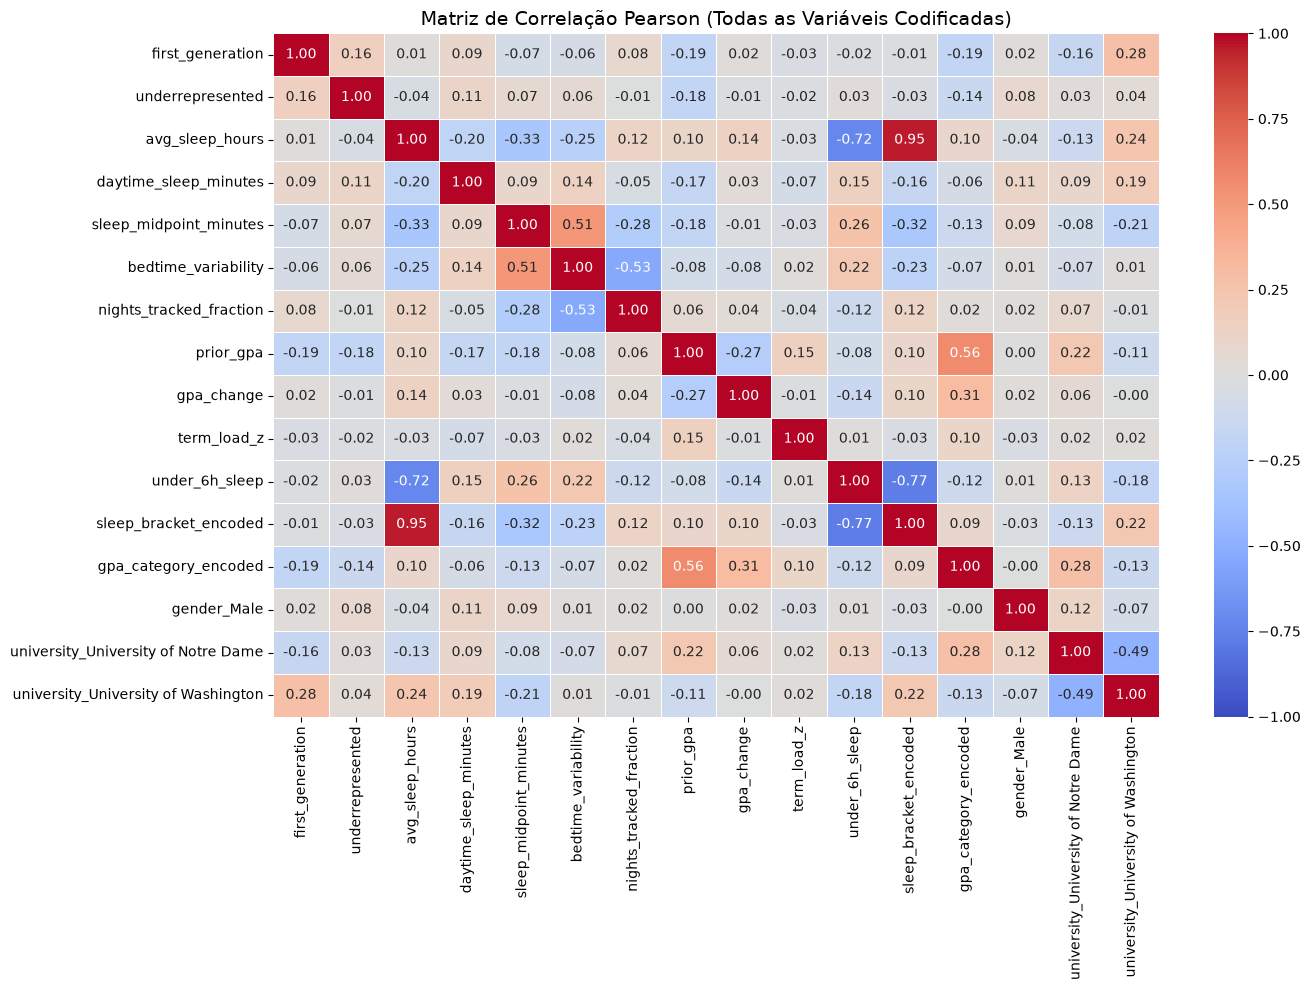

In [6]:
plt.figure(figsize=(14, 10))
matriz_corr = dataEncod.corr(method='pearson')

sns.heatmap(
    matriz_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5
)
plt.title('Matriz de Correlação Pearson (Todas as Variáveis Codificadas)', fontsize=14)
plt.tight_layout()
os.makedirs('../reports/figures', exist_ok=True)
plt.savefig('../reports/figures/matriz_correlacao_classificacao.png', bbox_inches='tight', dpi=300)
plt.show()

In [7]:
col_util = ['avg_sleep_hours', 'sleep_midpoint_minutes', 'prior_gpa', 'underrepresented', 'first_generation', 'gpa_category_encoded']

dataClassification = dataEncod[col_util].copy()

In [8]:
caminho_dados_processados = '../data/processed/'
os.makedirs(caminho_dados_processados, exist_ok=True)
dataClassification.to_csv(f'{caminho_dados_processados}dataset_classification.csv', index=False)